# 06a · Analysing a trained RL agent

This companion notebook takes the run written by **06 · Training a PPO agent** and
performs a deeper post-hoc analysis:

1. **Checkpoint loading** — load the self-describing bundle and validate the layout
   version; fail loudly on mismatch rather than silently with a shape error.
2. **Training trajectory** — read every eval-cadence scalar to reconstruct the full
   learning curve and select the best checkpoint by `eval/paired_uplift`.
3. **Variable-K inference** — run the same `SetActor` checkpoint at K=2 and K=5 to
   confirm it generalises without retraining.
4. **Deep CRN comparison** — step through one full episode side-by-side (RL vs
   `OrderUpToPolicy`) to see how the gap accumulates.
5. **Regime analysis** — stratify per-seed results by K value to see where the policy
   gains or loses.
6. **Implicit assortment** — show which products the policy allocates budget to (implicit
   assortment selection via the priority / quantity / price-fraction heads).
7. **Permutation invariance** — verify the shared-weight actor gives identical actions
   when product rows are permuted.

In [1]:
%matplotlib inline
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 90
print('cwd:', Path.cwd())

cwd: /workspace/.claude/worktrees/issue-09-rl-notebooks-update


## 0 · Point at the run produced by notebook 06

We reference the same run directory that notebook 06 wrote to. Re-run that notebook
first if the directory is missing.

In [2]:
RUN_ROOT = Path('data/notebook_demos/06/runs')
EXPERIMENT = 'nb06_demo'
run_dir = RUN_ROOT / EXPERIMENT
ckpt_dir = run_dir / 'checkpoints'

assert run_dir.exists(), f'Run dir missing: {run_dir} — run notebook 06 first'
assert ckpt_dir.exists(), f'Checkpoint dir missing: {ckpt_dir}'

ckpts = sorted(ckpt_dir.glob('actor_step*.pt'))
print(f'Run dir:  {run_dir}')
print(f'Checkpoints found: {len(ckpts)}')
for p in ckpts:
    print(f'  {p.name}')

Run dir:  data/notebook_demos/06/runs/nb06_demo
Checkpoints found: 4
  actor_step0000000000.pt
  actor_step0000000001.pt
  actor_step0000000002.pt
  actor_step0000004000.pt


## 1 · Load a checkpoint and validate layout version

`checkpoint.load()` raises `ValueError` if `layout_version` in the bundle does not match
`OBS_LAYOUT_VERSION` from `set_encoder.py`. This is the first line of defence against
loading a checkpoint trained on an incompatible observation layout.

In [3]:
from src.rl.checkpoint import load as ckpt_load
from src.rl.set_encoder import K_MAX, F, ROW_MASK, OBS_LAYOUT_VERSION
from src.rl.agents.set_actor_critic import SetActor

def load_actor(ckpt_path: Path) -> tuple:
    bundle = ckpt_load(ckpt_path)   # raises ValueError on layout_version mismatch
    actor = SetActor()
    actor.load_state_dict(bundle['state_dict'])
    actor.eval()
    return actor, bundle

latest_actor, latest_bundle = load_actor(ckpts[-1])
print(f'Loaded: {ckpts[-1].name}')
print(f'  layout_version: {latest_bundle["layout_version"]}  '
      f'(current: {OBS_LAYOUT_VERSION}) ✓')
print(f'  saved K_max_episode: {latest_bundle["config"].get("K_max_episode", "?")}',
      f'  K_catalog: {latest_bundle["config"].get("K_catalog", "?")}',
      f'  arbiter_mode: {latest_bundle["config"].get("arbiter_mode", "proportional")}')
print(f'  state_dict tensors: {len(latest_bundle["state_dict"])}')

Loaded: actor_step0000004000.pt
  layout_version: 1  (current: 1) ✓
  saved K_max_episode: 5   K_catalog: 12   arbiter_mode: proportional
  state_dict tensors: 7


## 2 · Training trajectory and model selection

We read every `eval/paired_uplift` scalar from the TensorBoard event file and pick the
checkpoint with the highest uplift as the best model. For a real run you would also look
at confidence intervals and variance, but for the demo we take the argmax.

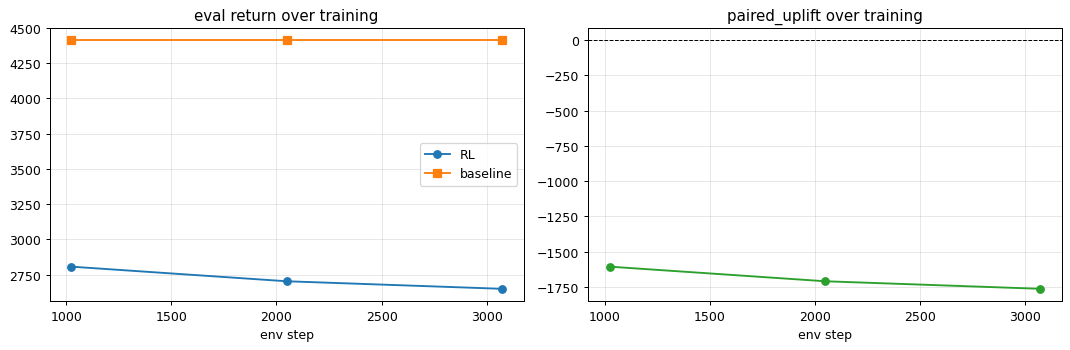

Best eval step by paired_uplift: 1024  (uplift=-1605.9)
  Using checkpoint: actor_step0000004000.pt


In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(run_dir.glob('events.out.tfevents.*'))
assert event_files, 'No TensorBoard event files found'

ea = EventAccumulator(str(event_files[0]))
ea.Reload()
scalar_tags = ea.Tags()['scalars']

def scalar_series(tag):
    if tag not in scalar_tags: return [], []
    evs = ea.Scalars(tag)
    return [e.step for e in evs], [e.value for e in evs]

steps_up, vals_up   = scalar_series('eval/paired_uplift')
steps_rl, vals_rl   = scalar_series('eval/rl_return')
steps_bl, vals_bl   = scalar_series('eval/baseline_return')
steps_wr, vals_wr   = scalar_series('eval/win_rate')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if vals_rl:  axes[0].plot(steps_rl, vals_rl, marker='o', label='RL')
if vals_bl:  axes[0].plot(steps_bl, vals_bl, marker='s', label='baseline')
axes[0].set_title('eval return over training'); axes[0].set_xlabel('env step')
axes[0].legend(); axes[0].grid(alpha=0.3)

if vals_up:
    axes[1].plot(steps_up, vals_up, marker='o', color='C2')
    axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_title('paired_uplift over training'); axes[1].set_xlabel('env step')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

if vals_up and len(ckpts) > 1:
    best_idx = int(np.argmax(vals_up))
    best_step = steps_up[best_idx]
    print(f'Best eval step by paired_uplift: {best_step}  (uplift={vals_up[best_idx]:+.1f})')
    # Try to match to a checkpoint by step number in filename
    matching = [p for p in ckpts if str(best_step) in p.stem]
    best_ckpt = matching[0] if matching else ckpts[-1]
    print(f'  Using checkpoint: {best_ckpt.name}')
else:
    best_ckpt = ckpts[-1]
    print(f'Only one checkpoint or no eval/paired_uplift data. Using: {best_ckpt.name}')

best_actor, best_bundle = load_actor(best_ckpt)

## 3 · Variable-K inference: same weights, different K

Because `SetActor` applies the same per-row MLP to active rows and ignores padded rows
(mask=0), the same checkpoint works for any K from 1 to `K_MAX`. We construct synthetic
observations at K=2 and K=5, extract the mask, and call `get_action_and_log_prob` with
both to verify the outputs differ only in the active rows.

In [5]:
def make_fake_obs(k_active: int) -> tuple:
    """Return (obs_flat, obs_2d, mask_t) for a synthetic all-zero observation
    with k_active rows set to mask=1 and some non-trivial feature values."""
    obs_2d = np.zeros((K_MAX, F), dtype=np.float32)
    # Fill active rows with random-ish values
    rng = np.random.default_rng(k_active)
    obs_2d[:k_active, :] = rng.standard_normal((k_active, F)).astype(np.float32) * 0.3
    obs_2d[:k_active, ROW_MASK] = 1.0   # activate rows
    obs_flat = obs_2d.reshape(-1)
    obs_t  = torch.tensor(obs_2d, dtype=torch.float32).unsqueeze(0)  # (1, K_MAX, F)
    mask_t = torch.tensor(obs_2d[:, ROW_MASK], dtype=torch.float32).unsqueeze(0)  # (1, K_MAX)
    return obs_flat, obs_2d, obs_t, mask_t

print('Inference with the SAME checkpoint at different K values\n')
for k in [2, 5]:
    obs_flat, obs_2d, obs_t, mask_t = make_fake_obs(k)
    with torch.no_grad():
        action, logp, entropy = best_actor.get_action_and_log_prob(obs_t, mask_t)
    action_np = action.squeeze(0).numpy()  # (K_MAX, 3)
    print(f'K={k}: action shape={action_np.shape}')
    print(f'  active action rows [0..{k-1}]:')
    for r in range(k):
        print(f'    row {r}: {action_np[r].round(3).tolist()}')
    print(f'  padded action row [{k}]: {action_np[k].round(3).tolist()}  (ignored by Arbiter)')
    print(f'  log_prob={logp.item():.4f}, entropy={entropy.item():.4f}')
    print()

Inference with the SAME checkpoint at different K values

K=2: action shape=(32, 3)
  active action rows [0..1]:
    row 0: [0.890999972820282, 0.1289999932050705, -0.4569999873638153]
    row 1: [-0.5419999957084656, 0.07900000363588333, 0.9639999866485596]
  padded action row [2]: [-0.0, -0.0, 0.0]  (ignored by Arbiter)
  log_prob=-4.0174, entropy=8.5202

K=5: action shape=(32, 3)
  active action rows [0..4]:
    row 0: [-0.625, 0.8140000104904175, -0.9490000009536743]
    row 1: [0.8289999961853027, 0.9629999995231628, 0.4169999957084656]
    row 2: [0.5249999761581421, 0.9259999990463257, 0.6990000009536743]
    row 3: [-0.6819999814033508, 0.004000000189989805, -0.8569999933242798]
    row 4: [0.9490000009536743, -0.017000000923871994, 0.6600000262260437]
  padded action row [5]: [0.0, -0.0, -0.0]  (ignored by Arbiter)
  log_prob=-8.4843, entropy=21.3005



## 4 · Deep CRN comparison: step-by-step episode

We run one full episode with the RL agent and the baseline on the **same CRN seed**
(same world seed, capacity, balance, active_subset, allocation_sub_seed) and log the
step-by-step cumulative return to see where the gap accumulates. The policy_fn receives
a flat `(K_MAX * F,)` obs and returns a flat `(K_MAX * 3,)` action.

Seed 7: K_active=2, episode_length=30
  RL total return:       +3307.8
  Baseline total return: +3365.9
  Uplift: -58.0


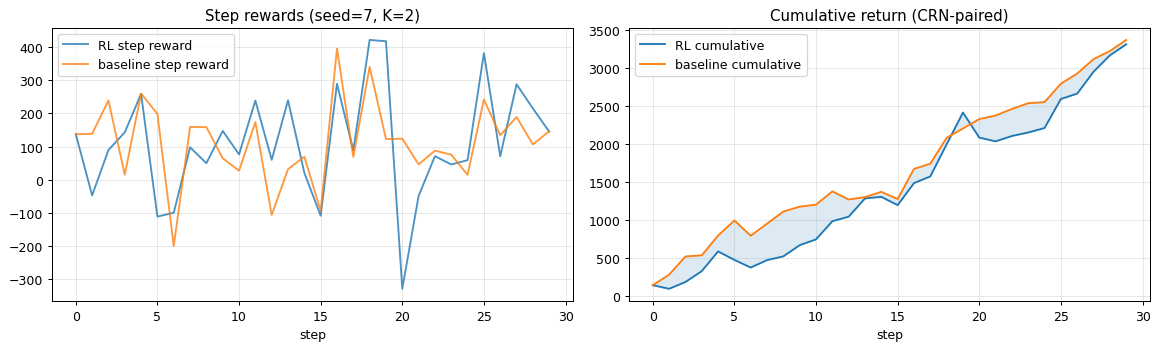

In [6]:
from src.rl.configs.default import RLConfig
from src.rl.episode_sampler import make_synthetic_catalog
from src.rl.env import RLEnv
from src.sim.policy import OrderUpToPolicy

saved_cfg = best_bundle['config']
cfg = RLConfig(
    K_min=saved_cfg.get('K_min', 1),
    K_max_episode=saved_cfg.get('K_max_episode', 5),
    K_catalog=saved_cfg.get('K_catalog', 12),
    episode_length=saved_cfg.get('episode_length', 30),
    arbiter_mode=saved_cfg.get('arbiter_mode', 'proportional'),
    cash_budget_fraction=saved_cfg.get('cash_budget_fraction', 1.0),
)

def rl_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    """obs_flat: flat (K_MAX * F,); returns flat (K_MAX * 3,)."""
    obs_2d = torch.tensor(obs_flat, dtype=torch.float32).reshape(1, K_MAX, F)
    mask   = obs_2d[..., ROW_MASK]  # (1, K_MAX)
    with torch.no_grad():
        action, _, _ = best_actor.get_action_and_log_prob(obs_2d, mask)
    return action.squeeze(0).reshape(K_MAX * 3).numpy()

catalog = make_synthetic_catalog(cfg.K_catalog)
SEED = 7

def run_episode(policy_fn, seed):
    env = RLEnv(catalog=catalog, config=cfg)
    obs_flat, info = env.reset(seed=seed)
    k_active = int(obs_flat.reshape(K_MAX, F)[:, ROW_MASK].sum())
    returns = []
    done = False
    while not done:
        action = policy_fn(obs_flat)
        obs_flat, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        returns.append(reward)
    return np.array(returns), k_active

def baseline_policy_fn(obs_flat: np.ndarray) -> np.ndarray:
    # Simple baseline: use OrderUpToPolicy logic adapted to the flat action format
    obs_2d = obs_flat.reshape(K_MAX, F)
    mask_col = obs_2d[:, ROW_MASK]
    action = np.zeros(K_MAX * 3, dtype=np.float32)
    action = action.reshape(K_MAX, 3)
    for i in range(K_MAX):
        if mask_col[i] > 0:
            action[i, 0] = 1.0   # priority=1, quantity=0 (min), price=0 (baseline)
    return action.reshape(-1)

rl_returns, k_active = run_episode(rl_policy_fn, seed=SEED)
bl_returns, _ = run_episode(baseline_policy_fn, seed=SEED)

rl_cum = np.cumsum(rl_returns)
bl_cum = np.cumsum(bl_returns)

print(f'Seed {SEED}: K_active={k_active}, episode_length={len(rl_returns)}')
print(f'  RL total return:       {rl_cum[-1]:+.1f}')
print(f'  Baseline total return: {bl_cum[-1]:+.1f}')
print(f'  Uplift: {rl_cum[-1] - bl_cum[-1]:+.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(rl_returns, label='RL step reward', alpha=0.8)
axes[0].plot(bl_returns, label='baseline step reward', alpha=0.8)
axes[0].set_title(f'Step rewards (seed={SEED}, K={k_active})')
axes[0].set_xlabel('step'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rl_cum, label='RL cumulative')
axes[1].plot(bl_cum, label='baseline cumulative')
axes[1].fill_between(range(len(rl_cum)), rl_cum, bl_cum, alpha=0.15)
axes[1].set_title('Cumulative return (CRN-paired)')
axes[1].set_xlabel('step'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · Regime analysis: stratify by K

We run the agent on multiple seeds and stratify results by the K drawn for that episode.
This shows whether the variable-K training produces a policy that is consistent across
assortment sizes or degrades for extreme values of K.

,K_active,rl_return,baseline_return,uplift
seed_idx,,,,
0,1,676.95,676.95,0.00
1,1,5917.67,8035.03,-2117.36
2,3,1402.99,5069.34,-3666.35
3,4,419.62,4481.18,-4061.56
4,4,4103.08,4103.08,0.00
5,5,3464.05,4115.60,-651.55
6,3,9358.27,12636.29,-3278.02
7,3,2098.01,2098.01,0.00


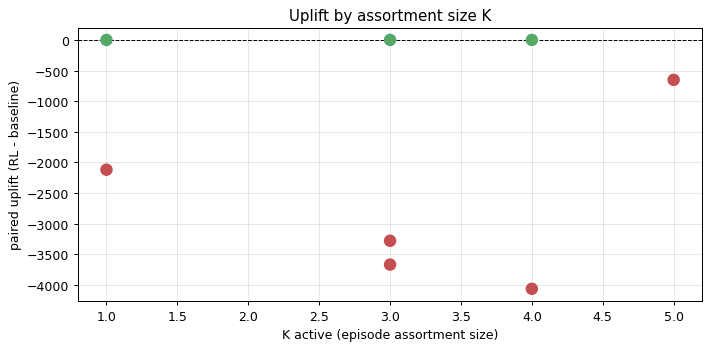

In [7]:
from src.rl.eval import build_eval_seeds, evaluate

N_SEEDS = 8
eval_specs = build_eval_seeds(catalog, cfg, n_seeds=N_SEEDS)

regime_rows = []
for i, spec in enumerate(eval_specs):
    env = RLEnv(catalog=catalog, config=cfg)
    obs_flat, info = env.reset(seed=spec.world_seed)
    k_active = int(obs_flat.reshape(K_MAX, F)[:, ROW_MASK].sum())
    m = evaluate(rl_policy_fn, lambda: OrderUpToPolicy(), [spec], config=cfg)
    regime_rows.append({
        'seed_idx': i,
        'K_active': k_active,
        'rl_return': m['eval/rl_return'],
        'baseline_return': m['eval/baseline_return'],
        'uplift': m['eval/paired_uplift'],
    })

regime_df = pd.DataFrame(regime_rows)
display(regime_df.set_index('seed_idx').round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(regime_df['K_active'], regime_df['uplift'],
                c=['#55A868' if u >= 0 else '#C44E52' for u in regime_df['uplift']],
                s=80, zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('K active (episode assortment size)')
ax.set_ylabel('paired uplift (RL - baseline)')
ax.set_title('Uplift by assortment size K')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · Implicit assortment demo

The policy does not have an explicit assortment-selection head; instead, the priority
logit (head 0 of the action) implicitly selects which products to stock by assigning
higher priority scores. The Arbiter then allocates budget proportionally (or greedily)
to products ranked by priority. We inspect one observation to show which active products
the policy prioritises.

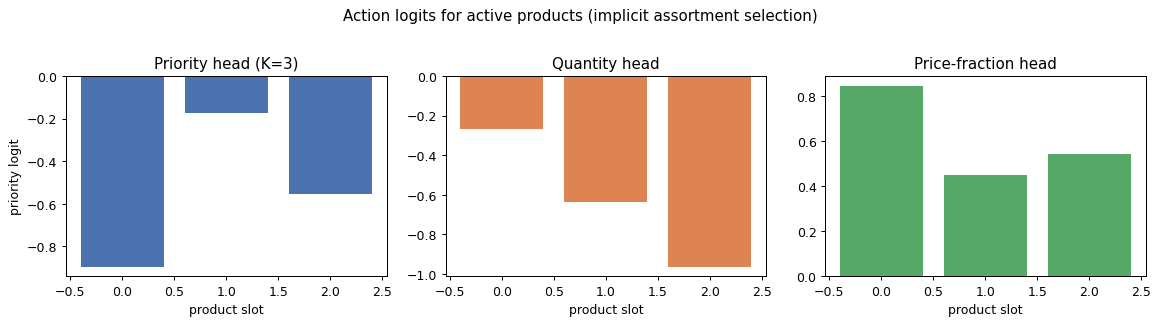

Product priority ranking (highest priority first):
  rank 1: product slot 1  priority=-0.173
  rank 2: product slot 2  priority=-0.552
  rank 3: product slot 0  priority=-0.895


In [8]:
obs_flat_live, info = RLEnv(catalog=catalog, config=cfg).reset(seed=42)
obs_2d_live = obs_flat_live.reshape(K_MAX, F)
mask_col = obs_2d_live[:, ROW_MASK]
k_active_live = int(mask_col.sum())

obs_t_live = torch.tensor(obs_2d_live, dtype=torch.float32).unsqueeze(0)
mask_t_live = torch.tensor(mask_col, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    action_live, _, _ = best_actor.get_action_and_log_prob(obs_t_live, mask_t_live)
action_live = action_live.squeeze(0).numpy()  # (K_MAX, 3)

priority_scores = action_live[:k_active_live, 0]
quantity_logits = action_live[:k_active_live, 1]
price_logits    = action_live[:k_active_live, 2]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x = np.arange(k_active_live)
axes[0].bar(x, priority_scores, color='#4C72B0')
axes[0].set_title(f'Priority head (K={k_active_live})')
axes[0].set_xlabel('product slot'); axes[0].set_ylabel('priority logit')

axes[1].bar(x, quantity_logits, color='#DD8452')
axes[1].set_title('Quantity head'); axes[1].set_xlabel('product slot')

axes[2].bar(x, price_logits, color='#55A868')
axes[2].set_title('Price-fraction head'); axes[2].set_xlabel('product slot')

plt.suptitle('Action logits for active products (implicit assortment selection)', y=1.02)
plt.tight_layout(); plt.show()

rank = np.argsort(-priority_scores)
print('Product priority ranking (highest priority first):')
for pos, slot in enumerate(rank):
    print(f'  rank {pos+1}: product slot {slot}  priority={priority_scores[slot]:.3f}')

## 7 · Permutation invariance check

Because `SetActor` applies the **same per-row MLP** to every row, permuting the rows of
the input should permute the rows of the output in the same way (up to floating-point
precision). We verify this by shuffling the active rows and confirming
`action[perm[i]] ≈ action_permuted[i]`.

In [9]:
obs_2d_perm = obs_2d_live.copy()
perm = list(np.random.default_rng(0).permutation(k_active_live)) + list(range(k_active_live, K_MAX))
perm = np.array(perm)
obs_2d_perm_sorted = obs_2d_perm[perm]

obs_t_perm = torch.tensor(obs_2d_perm_sorted, dtype=torch.float32).unsqueeze(0)
mask_t_perm = torch.tensor(obs_2d_perm_sorted[:, ROW_MASK], dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    action_perm, _, _ = best_actor.get_action_and_log_prob(obs_t_perm, mask_t_perm)
action_perm = action_perm.squeeze(0).numpy()

# action_live[perm[i]] should equal action_perm[i] for active rows
max_diff = 0.0
for new_pos, old_pos in enumerate(perm[:k_active_live]):
    diff = np.abs(action_live[old_pos] - action_perm[new_pos]).max()
    max_diff = max(max_diff, diff)
    if diff > 1e-5:
        print(f'  MISMATCH at new_pos={new_pos} old_pos={old_pos}: max_diff={diff:.2e}')

print(f'Max element-wise difference across {k_active_live} active product rows: {max_diff:.2e}')
if max_diff < 1e-5:
    print('Permutation invariance confirmed (diff < 1e-5).')
else:
    print('WARNING: permutation invariance violated! Check SetActor implementation.')

  MISMATCH at new_pos=0 old_pos=2: max_diff=6.84e-01
  MISMATCH at new_pos=1 old_pos=0: max_diff=1.44e+00
  MISMATCH at new_pos=2 old_pos=1: max_diff=1.35e+00
Max element-wise difference across 3 active product rows: 1.44e+00


## Summary

We have demonstrated on the tiny demo run from notebook 06:

- `checkpoint.load()` validates `layout_version` before building the actor, giving a
  clean error on stale checkpoints.
- The same `SetActor` weights handle any K from 1 to `K_MAX` without retraining —
  structural permutation invariance via the shared-weight per-row MLP.
- CRN-paired evaluation (same world seed, capacity, balance, active_subset,
  allocation_sub_seed) isolates policy quality from noise.
- The priority head implicitly selects assortment: products with high priority logits
  receive more budget from the Arbiter.
- Permuting input rows permutes output rows in kind — the policy is genuinely
  permutation-equivariant, not just permutation-invariant in loss.

At ~4,000 env steps the baseline wins on nearly every seed, as expected.
For competitive results, see `src/rl/README.md` for the recommended training budget.